# PWA conservation analysis (msa-swap)

Test whether Boltz's MSA-module pair-weighted-averaging attention (`pwa_weights`) reads the MSA as a fold prior independent of the query.

Conditions (all share the WT MSA hits — only row 0 differs):
- `original`: WT seq + WT MSA
- `seq_18553`: mutant seq + WT MSA
- `random_freq`: AA-frequency-matched random seq + WT MSA
- `random_uniform`: uniform random seq + WT MSA

For each (condition, recycling step, MSA layer):
- column attention `A_j = mean_{h,i} W[h,i,j]` — how much position j is read from
- row entropy `H_i = -Σ_j W[h,i,j] log W[h,i,j]` averaged over heads

Then:
1. Spearman(A_j, conservation_j) per (layer, condition) — cheat-sheet hypothesis: high in all conditions including the random ones.
2. JS divergence between A_j across conditions per layer — cheat-sheet: random/WT ≈ original/WT.
3. Layer-wise dynamics across the 4 MSA layers.

In [1]:
from pathlib import Path
import sys

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

_SRC = Path.cwd()
while _SRC.name and not (_SRC / 'protein_interpretability').is_dir():
    _SRC = _SRC.parent
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

from protein_interpretability.msa_analysis import (
    msa_to_array,
    column_aa_distributions,
    conservation_per_position,
    ALPHABET,
)

In [2]:
RUN_DIR = Path('/Users/thomasbush/tmp-data/tmp_data/hidden_reps/boltz_results_chunk_0')
ATTN_DIR = RUN_DIR / 'attention'

# Each condition's a3m has the same homolog rows; row 0 = the condition's query.
# WT conservation comes from the original a3m (row 0 = WT).
MSA_DIR = Path('/Users/thomasbush/tmp-data/tmp_data/msa_analysis/sequences')
WT_MSA_PATH = MSA_DIR / 'original' / 'msa' / 'A_protein_.a3m'
MUT_MSA_PATH = MSA_DIR / 'seq_18553' / 'msa' / '18553_protein_.a3m'

CONDITIONS = ['original', 'seq_18553', 'random_freq', 'random_uniform']
COND_PALETTE = dict(zip(CONDITIONS, sns.color_palette('tab10', n_colors=len(CONDITIONS))))

## Load pwa_weights

Each `.pt` is `{token_mask, step_<k>: {msa_layer_<l>_pwa_weights: (1,H,N,N)}}`. Discover steps and layers from the file, drop chain padding via `token_mask`.

In [4]:
def load_pwa(path: Path):
    blob = torch.load(path, map_location='cpu', weights_only=False)
    token_mask = blob['token_mask'].squeeze(0).bool().numpy()  # (N,)
    keep = np.where(token_mask)[0]
    steps = {}
    for k, v in blob.items():
        if not isinstance(k, str) or not k.startswith('step_'):
            continue
        layers = {}
        for lk, lv in v.items():
            # lk like 'msa_layer_<i>_pwa_weights'
            li = int(lk.split('_')[2])
            w = lv.squeeze(0).float().numpy()  # (H, N, N)
            w = w[:, keep][:, :, keep]
            layers[li] = w
        steps[k] = dict(sorted(layers.items()))
    return token_mask, dict(sorted(steps.items(), key=lambda kv: int(kv[0].split('_')[1])))

data = {}
for cond in CONDITIONS:
    mask, steps = load_pwa(ATTN_DIR / f'{cond}_attention.pt')
    data[cond] = {'mask': mask, 'steps': steps}

STEP_KEYS = list(next(iter(data.values()))['steps'].keys())
LAYER_IDS = list(next(iter(data.values()))['steps'][STEP_KEYS[0]].keys())
N = data['original']['mask'].sum()
H = next(iter(data['original']['steps'][STEP_KEYS[0]].values())).shape[0]
print(f'N residues: {N}  heads: {H}')
print(f'recycling steps saved: {STEP_KEYS}')
print(f'MSA layers: {LAYER_IDS}')

N residues: 238  heads: 8
recycling steps saved: ['step_0', 'step_5', 'step_10']
MSA layers: [0, 1, 2, 3]


## Derived signals: column attention A_j and row entropy H_i

`A_j` averages over heads then over the query row index `i` (W is row-stochastic so `Σ_j A_j = N`; we normalise to a probability over `j`).

`H_i` is the mean over heads of the per-row Shannon entropy of `W[h,i,:]`, in nats.

In [5]:
def column_attention(W):  # (H, N, N) -> (N,)
    a = W.mean(axis=(0, 1))
    return a / a.sum()

def row_entropy(W, eps=1e-12):  # (H, N, N) -> (N,)
    p = np.clip(W, eps, 1.0)
    h = -(p * np.log(p)).sum(axis=-1)  # (H, N)
    return h.mean(axis=0)

def per_head_column_attention(W):  # (H, N, N) -> (H, N)
    a = W.mean(axis=1)
    return a / a.sum(axis=-1, keepdims=True)

A = {c: {s: {l: column_attention(W) for l, W in data[c]['steps'][s].items()} for s in STEP_KEYS} for c in CONDITIONS}
Hent = {c: {s: {l: row_entropy(W) for l, W in data[c]['steps'][s].items()} for s in STEP_KEYS} for c in CONDITIONS}
A_h = {c: {s: {l: per_head_column_attention(W) for l, W in data[c]['steps'][s].items()} for s in STEP_KEYS} for c in CONDITIONS}

## MSA conservation profile

Two definitions, both length-N:
- `cons_entropy[j] = 1 - H_col[j] / log(K)` — column entropy over the 20+gap alphabet (k = 21).
- `cons_max[j] = max_a freq[j, a]` — frequency of the consensus AA in column j.

Computed from the WT MSA. Mutant positions in `seq_18553` are recovered as the residue-disagreement mask between the two row-0 sequences.

In [6]:
wt_arr, wt_ref, _ = msa_to_array(WT_MSA_PATH)
mut_arr, mut_ref, _ = msa_to_array(MUT_MSA_PATH)

wt_dist = column_aa_distributions(wt_arr)
K = wt_dist.shape[1]
col_entropy = -(wt_dist * np.log(np.clip(wt_dist, 1e-12, 1.0))).sum(axis=-1)
cons_entropy = 1.0 - col_entropy / np.log(K)
cons_max = wt_dist.max(axis=-1)
cons_qmatch = conservation_per_position(wt_arr)  # fraction-of-rows-matching-WT

assert wt_arr.shape[1] == N, f'MSA L ({wt_arr.shape[1]}) != attention N ({N})'
mut_positions = np.where(np.frombuffer(wt_ref.encode(), np.uint8) != np.frombuffer(mut_ref.encode(), np.uint8))[0]
print(f'WT length: {len(wt_ref)}  hits: {wt_arr.shape[0]-1}')
print(f'mutant positions ({len(mut_positions)}): {mut_positions.tolist()}')

WT length: 238  hits: 767
mutant positions (96): [1, 2, 7, 10, 11, 13, 15, 18, 21, 22, 24, 29, 32, 33, 34, 36, 37, 38, 42, 43, 45, 46, 48, 54, 60, 63, 64, 65, 66, 67, 71, 72, 75, 76, 78, 81, 82, 83, 86, 87, 92, 94, 96, 99, 100, 103, 106, 109, 110, 112, 113, 117, 119, 121, 122, 127, 128, 129, 130, 131, 134, 137, 144, 145, 147, 151, 152, 155, 156, 158, 161, 162, 169, 171, 175, 176, 177, 179, 182, 186, 187, 189, 190, 191, 193, 198, 206, 208, 211, 215, 220, 222, 225, 226, 227, 231]


## 1. Per-layer Spearman(A_j, conservation_j) — bar plot

The decisive view. If the random conditions track `original`, the model is reading conservation regardless of query.

In [7]:
rows = []
for cond in CONDITIONS:
    for s in STEP_KEYS:
        for l in LAYER_IDS:
            a = A[cond][s][l]
            for cons_name, cons in [('entropy', cons_entropy), ('max', cons_max)]:
                r, _ = spearmanr(a, cons)
                rows.append({'cond': cond, 'step': s, 'layer': l, 'cons': cons_name, 'rho': r})
df_rho = pd.DataFrame(rows)
df_rho.head()

,cond,step,layer,cons,rho
0,original,step_0,0,entropy,0.148288
1,original,step_0,0,max,0.191729
2,original,step_0,1,entropy,-0.465128
3,original,step_0,1,max,-0.461855
4,original,step_0,2,entropy,0.071700


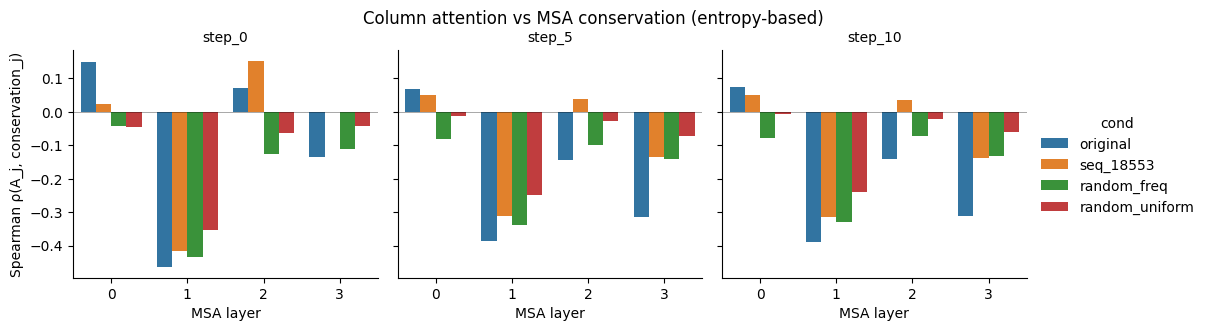

In [8]:
g = sns.catplot(
    data=df_rho[df_rho['cons'] == 'entropy'],
    x='layer', y='rho', hue='cond', col='step',
    kind='bar', palette=COND_PALETTE, height=3.2, aspect=1.1,
    hue_order=CONDITIONS,
)
g.set_axis_labels('MSA layer', 'Spearman ρ(A_j, conservation_j)')
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.axhline(0, color='k', lw=0.6, alpha=0.4)
g.fig.suptitle('Column attention vs MSA conservation (entropy-based)', y=1.02)
plt.show()

## 2. Cross-condition JS divergence on A_j per layer

Cheat-sheet: random/WT and original/WT have small JS at every MSA layer.

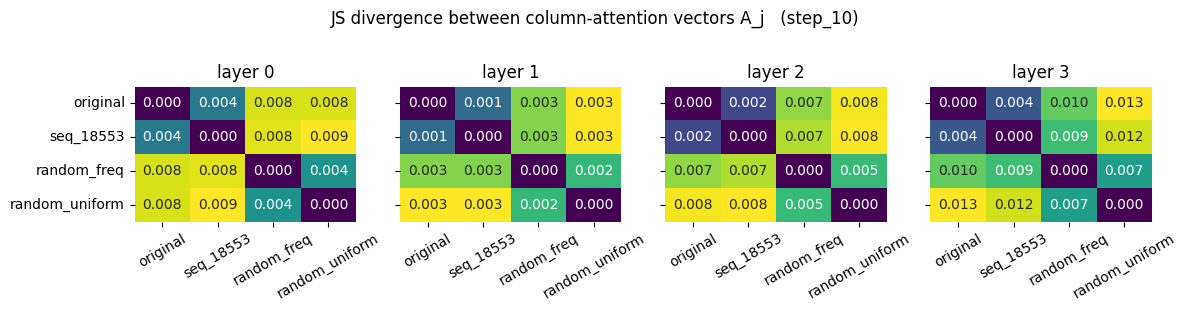

In [9]:
def js(p, q, eps=1e-12):
    p = np.clip(p, eps, 1.0); q = np.clip(q, eps, 1.0)
    p = p / p.sum(); q = q / q.sum()
    m = 0.5 * (p + q)
    return 0.5 * (p * np.log(p / m)).sum() + 0.5 * (q * np.log(q / m)).sum()

step_focus = STEP_KEYS[-1]
fig, axes = plt.subplots(1, len(LAYER_IDS), figsize=(3.0 * len(LAYER_IDS), 3.0), sharey=True)
for ax, l in zip(axes, LAYER_IDS):
    M = np.zeros((len(CONDITIONS), len(CONDITIONS)))
    for i, ci in enumerate(CONDITIONS):
        for j, cj in enumerate(CONDITIONS):
            M[i, j] = js(A[ci][step_focus][l], A[cj][step_focus][l])
    sns.heatmap(M, annot=True, fmt='.3f', xticklabels=CONDITIONS, yticklabels=CONDITIONS,
                cmap='viridis', ax=ax, cbar=False)
    ax.set_title(f'layer {l}')
    ax.tick_params(axis='x', rotation=30)
fig.suptitle(f'JS divergence between column-attention vectors A_j   ({step_focus})', y=1.02)
plt.tight_layout(); plt.show()

## 3. A_j curves overlaid across conditions, per layer

Pick a recycling step and overlay all four condition curves; mark the mutant positions for `seq_18553`.

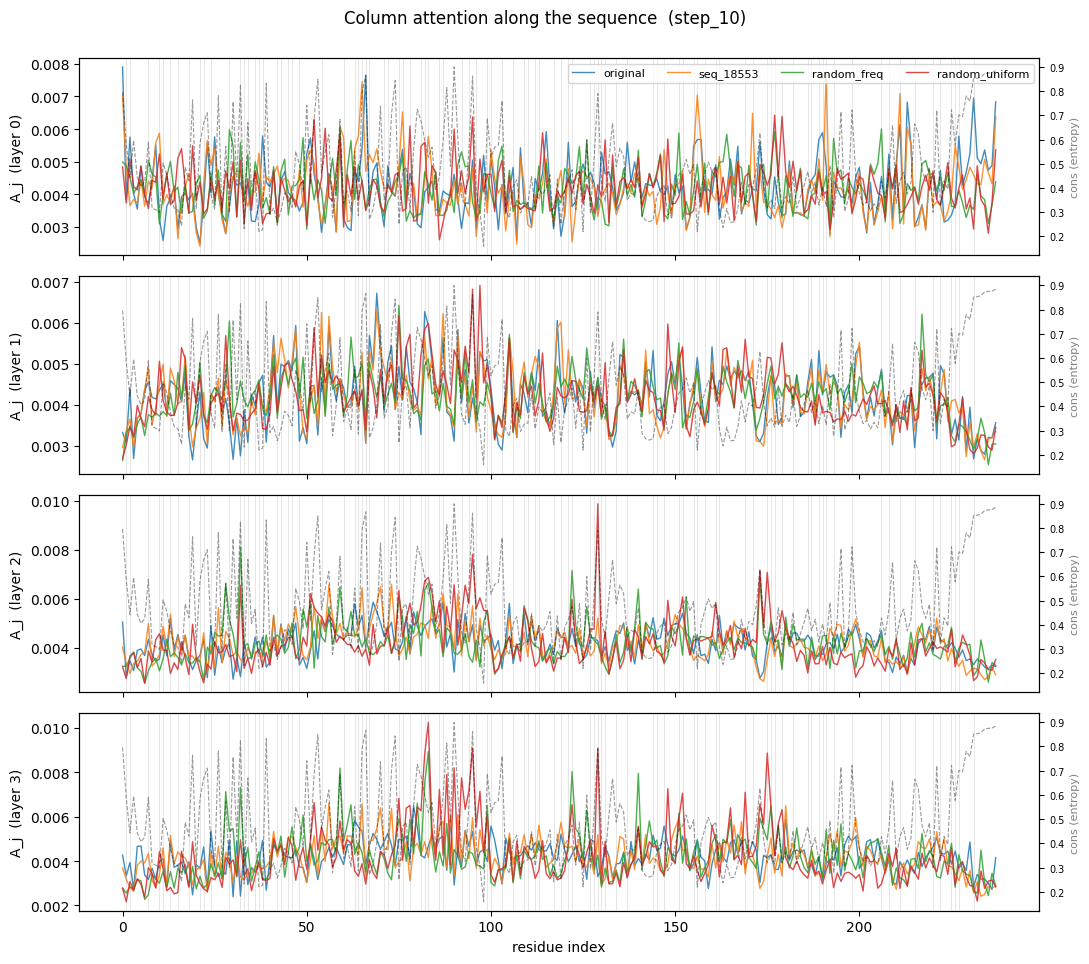

In [10]:
step_focus = STEP_KEYS[-1]
fig, axes = plt.subplots(len(LAYER_IDS), 1, figsize=(11, 2.4 * len(LAYER_IDS)), sharex=True)
if len(LAYER_IDS) == 1:
    axes = [axes]
for ax, l in zip(axes, LAYER_IDS):
    for cond in CONDITIONS:
        ax.plot(A[cond][step_focus][l], color=COND_PALETTE[cond], lw=1.0, label=cond, alpha=0.85)
    for p in mut_positions:
        ax.axvline(p, color='grey', lw=0.4, alpha=0.35)
    ax2 = ax.twinx()
    ax2.plot(cons_entropy, color='k', lw=0.8, alpha=0.4, ls='--')
    ax2.set_ylabel('cons (entropy)', color='grey', fontsize=8)
    ax2.tick_params(axis='y', labelsize=7)
    ax.set_ylabel(f'A_j  (layer {l})')
axes[0].legend(loc='upper right', ncol=4, fontsize=8)
axes[-1].set_xlabel('residue index')
fig.suptitle(f'Column attention along the sequence  ({step_focus})', y=1.0)
plt.tight_layout(); plt.show()

## 4. Per-head column attention — does the average mask specialised heads?

Heatmap (heads × layers) of Spearman(A_j_head, conservation_j) for the focus step. If a few heads are conservation-locked while others are sequence-aware, the head average could obscure the picture.

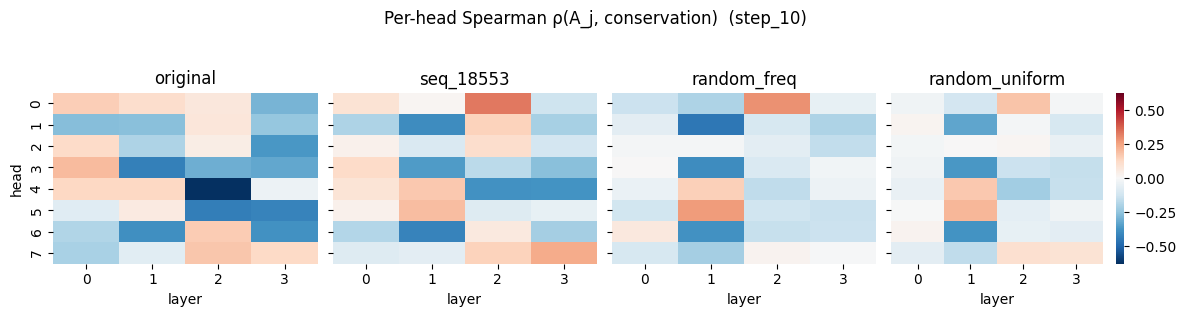

In [11]:
step_focus = STEP_KEYS[-1]
fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(3.0 * len(CONDITIONS), 3.0), sharey=True)
vmax = 0.0
mats = {}
for cond in CONDITIONS:
    M = np.zeros((H, len(LAYER_IDS)))
    for li, l in enumerate(LAYER_IDS):
        for h in range(H):
            r, _ = spearmanr(A_h[cond][step_focus][l][h], cons_entropy)
            M[h, li] = r
    mats[cond] = M
    vmax = max(vmax, np.abs(M).max())
for ax, cond in zip(axes, CONDITIONS):
    sns.heatmap(mats[cond], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax, ax=ax,
                xticklabels=LAYER_IDS, yticklabels=range(H), cbar=ax is axes[-1])
    ax.set_title(cond)
    ax.set_xlabel('layer')
axes[0].set_ylabel('head')
fig.suptitle(f'Per-head Spearman ρ(A_j, conservation)  ({step_focus})', y=1.04)
plt.tight_layout(); plt.show()

## 5. Row entropy H_i — is the model focused or diffuse?

Per-residue attention entropy. Drops at conserved positions = focused reads; flat at high entropy = diffuse / uninformative.

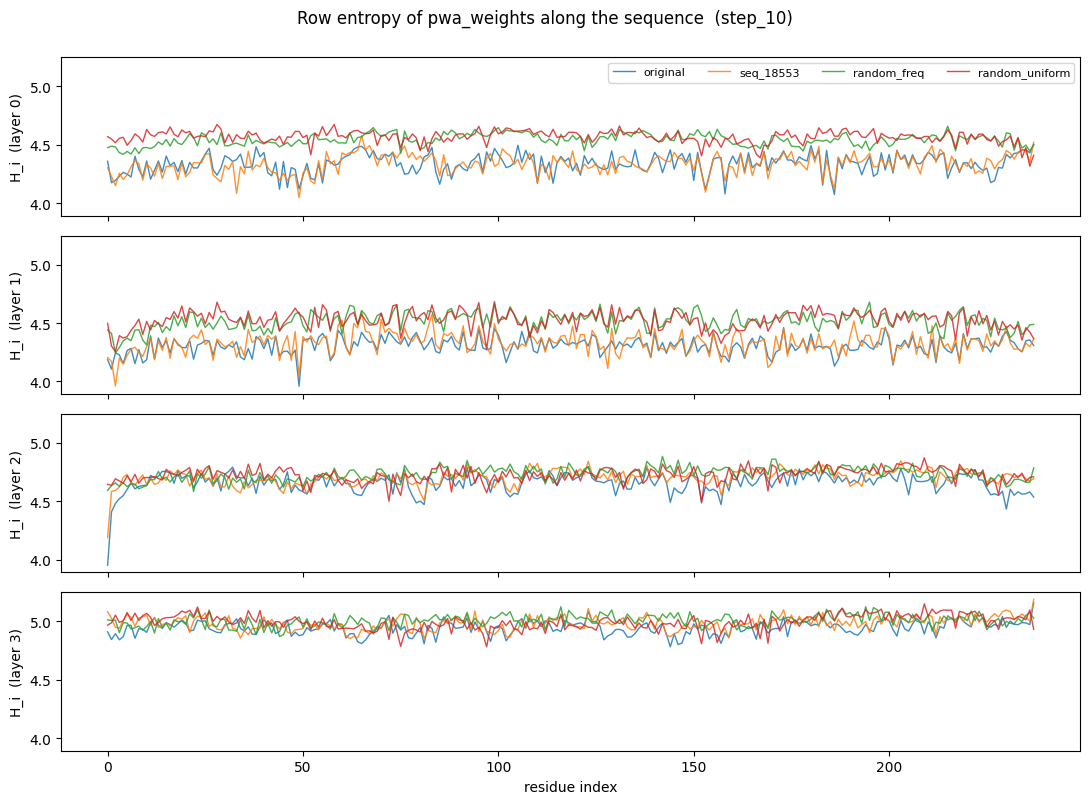

In [12]:
step_focus = STEP_KEYS[-1]
fig, axes = plt.subplots(len(LAYER_IDS), 1, figsize=(11, 2.0 * len(LAYER_IDS)), sharex=True, sharey=True)
if len(LAYER_IDS) == 1:
    axes = [axes]
for ax, l in zip(axes, LAYER_IDS):
    for cond in CONDITIONS:
        ax.plot(Hent[cond][step_focus][l], color=COND_PALETTE[cond], lw=1.0, label=cond, alpha=0.85)
    ax.set_ylabel(f'H_i  (layer {l})')
axes[0].legend(loc='upper right', ncol=4, fontsize=8)
axes[-1].set_xlabel('residue index')
fig.suptitle(f'Row entropy of pwa_weights along the sequence  ({step_focus})', y=1.0)
plt.tight_layout(); plt.show()

## 6. Attention onto mutated positions (seq_18553)

For each condition, what fraction of total column attention falls on the mutated positions? If the model is sequence-aware, `seq_18553` should redistribute attention onto / away from those positions vs the random conditions.

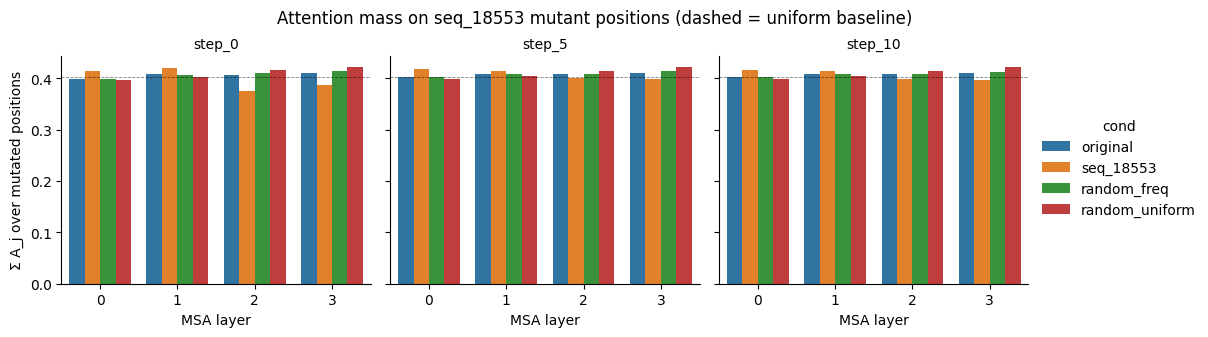

In [14]:
rows = []
frac_pos = len(mut_positions) / N
for cond in CONDITIONS:
    for s in STEP_KEYS:
        for l in LAYER_IDS:
            a = A[cond][s][l]
            rows.append({
                'cond': cond, 'step': s, 'layer': l,
                'frac_attention_on_muts': float(a[mut_positions].sum()),
                'expected_uniform': frac_pos,
            })
df_mut = pd.DataFrame(rows)
g = sns.catplot(data=df_mut, x='layer', y='frac_attention_on_muts', hue='cond', col='step',
                kind='bar', palette=COND_PALETTE, height=3.2, aspect=1.1, hue_order=CONDITIONS)
for ax in g.axes.flat:
    ax.axhline(frac_pos, color='k', ls='--', lw=0.6, alpha=0.5)
g.set_axis_labels('MSA layer', 'Σ A_j over mutated positions')
g.set_titles('{col_name}')
g.fig.suptitle('Attention mass on seq_18553 mutant positions (dashed = uniform baseline)', y=1.04)
plt.show()

## 7. Coevolution (mutual information) instead of conservation

Per-column coevolution score: APC-corrected mean MI between column j and all other columns. Hypothesis: A_j correlates **positively** with this score, i.e. attention concentrates on columns that carry coevolutionary signal — which would explain the negative correlation with simple conservation seen in plot 1.


In [15]:
from itertools import combinations

def column_mi_matrix(arr, alphabet_size=21):
    # arr: (n_seqs, L) uint8 ascii. Map ascii -> [0, K-1] using ALPHABET.
    code_to_idx = {ord(c): k for k, c in enumerate(ALPHABET)}
    L = arr.shape[1]
    enc = np.full(arr.shape, alphabet_size, dtype=np.int8)  # K = "other" bin
    for code, k in code_to_idx.items():
        enc[arr == code] = k
    K = alphabet_size + 1
    n = arr.shape[0]

    # Single-column entropies
    p1 = np.zeros((L, K), dtype=np.float64)
    for k in range(K):
        p1[:, k] = (enc == k).sum(axis=0)
    p1 /= n
    H1 = -(p1 * np.where(p1 > 0, np.log(np.clip(p1, 1e-12, 1)), 0)).sum(axis=-1)

    # Pairwise MI via joint counts; vectorise per row of i.
    MI = np.zeros((L, L), dtype=np.float32)
    for i in range(L):
        # joint(j, a, b) = count over rows where col_i = a and col_j = b
        ai = enc[:, i]                                              # (n,)
        # one-hot of col i: (n, K)
        oh_i = np.eye(K, dtype=np.float32)[ai]
        # one-hot of cols j>i in chunks to bound memory
        for j_start in range(i + 1, L, 64):
            j_end = min(L, j_start + 64)
            oh_j = np.eye(K, dtype=np.float32)[enc[:, j_start:j_end]]   # (n, M, K)
            # joint counts: (M, K_i, K_j)
            joint = np.einsum('nk,nmj->mkj', oh_i, oh_j) / n
            pi = joint.sum(axis=2)        # (M, K_i) ~= p1[i]
            pj = joint.sum(axis=1)        # (M, K_j)
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = joint / np.maximum(pi[:, :, None] * pj[:, None, :], 1e-12)
                term = np.where(joint > 0, joint * np.log(np.clip(ratio, 1e-12, None)), 0.0)
            mi = term.sum(axis=(1, 2)).astype(np.float32)
            MI[i, j_start:j_end] = mi
            MI[j_start:j_end, i] = mi
    return MI, H1

def apc_correct(MI):
    # Standard APC: MI_apc(i,j) = MI(i,j) - mean(MI[i,:]) * mean(MI[:,j]) / mean(MI)
    M = MI.copy()
    np.fill_diagonal(M, np.nan)
    row_mean = np.nanmean(M, axis=1)
    col_mean = np.nanmean(M, axis=0)
    grand   = np.nanmean(M)
    apc = MI - np.outer(row_mean, col_mean) / max(grand, 1e-12)
    np.fill_diagonal(apc, 0.0)
    return apc

# Subsample MSA for tractability (MI is O(L^2 * n))
rng = np.random.default_rng(0)
max_seqs = 2000
idx = np.arange(wt_arr.shape[0])
if wt_arr.shape[0] > max_seqs:
    keep = np.concatenate(([0], rng.choice(np.arange(1, wt_arr.shape[0]), size=max_seqs - 1, replace=False)))
    sub = wt_arr[keep]
else:
    sub = wt_arr
print(f'computing MI on {sub.shape[0]} rows x {sub.shape[1]} cols ...')
MI, H1 = column_mi_matrix(sub)
APC = apc_correct(MI)

sep = 5
ii, jj = np.indices(APC.shape)
mask = np.abs(ii - jj) > sep
coevo_apc = np.where(mask, APC, 0.0).sum(axis=1) / mask.sum(axis=1)   # mean APC per column
coevo_mi  = np.where(mask, MI,  0.0).sum(axis=1) / mask.sum(axis=1)
print('coevo APC range:', coevo_apc.min(), coevo_apc.max())


computing MI on 768 rows x 238 cols ...
coevo APC range: -0.019111540874195518 -0.003804152232434781


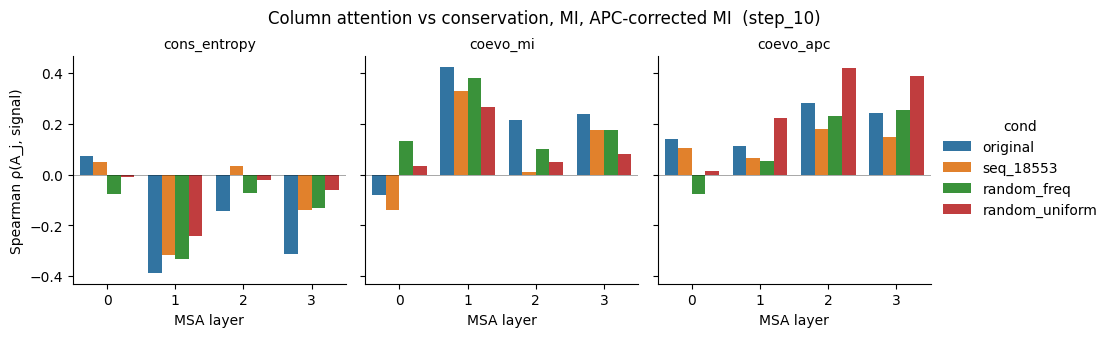

In [16]:
rows = []
for cond in CONDITIONS:
    for s in STEP_KEYS:
        for l in LAYER_IDS:
            a = A[cond][s][l]
            for name, v in [('coevo_apc', coevo_apc), ('coevo_mi', coevo_mi), ('cons_entropy', cons_entropy)]:
                r, _ = spearmanr(a, v)
                rows.append({'cond': cond, 'step': s, 'layer': l, 'signal': name, 'rho': r})
df_co = pd.DataFrame(rows)

g = sns.catplot(
    data=df_co[df_co['step'] == STEP_KEYS[-1]],
    x='layer', y='rho', hue='cond', col='signal', kind='bar',
    palette=COND_PALETTE, height=3.2, aspect=1.0, hue_order=CONDITIONS,
    col_order=['cons_entropy', 'coevo_mi', 'coevo_apc'],
)
for ax in g.axes.flat:
    ax.axhline(0, color='k', lw=0.6, alpha=0.4)
g.set_axis_labels('MSA layer', 'Spearman ρ(A_j, signal)')
g.set_titles('{col_name}')
g.fig.suptitle(f'Column attention vs conservation, MI, APC-corrected MI  ({STEP_KEYS[-1]})', y=1.04)
plt.show()


## 8. Structural contacts — does attention land on contact-forming residues?

Use the ESMFold WT structure (or any reference PDB) to compute the per-column contact density (number of long-range C_α contacts under 8 Å). Correlate A_j with that score per layer × condition.


In [17]:
from pathlib import Path

REF_PDB = Path('/Users/thomasbush/tmp-data/tmp_data/msa_analysis/sequences/original/esmfold/structure.pdb')

def load_ca_coords(pdb_path):
    coords = []
    with open(pdb_path) as f:
        for line in f:
            if line.startswith('ATOM') and line[12:16].strip() == 'CA':
                x, y, z = float(line[30:38]), float(line[38:46]), float(line[46:54])
                coords.append((x, y, z))
    return np.asarray(coords, dtype=np.float32)

ca = load_ca_coords(REF_PDB)
assert ca.shape[0] == N, f'PDB has {ca.shape[0]} CA, attention has {N}'

D = np.linalg.norm(ca[:, None] - ca[None, :], axis=-1)
contact = (D < 8.0).astype(np.float32)
ii, jj = np.indices(contact.shape)
contact = np.where(np.abs(ii - jj) > 5, contact, 0.0)
contact_density = contact.sum(axis=1)
print('mean contact density:', contact_density.mean(), 'max:', contact_density.max())


mean contact density: 2.8907564 max: 10.0


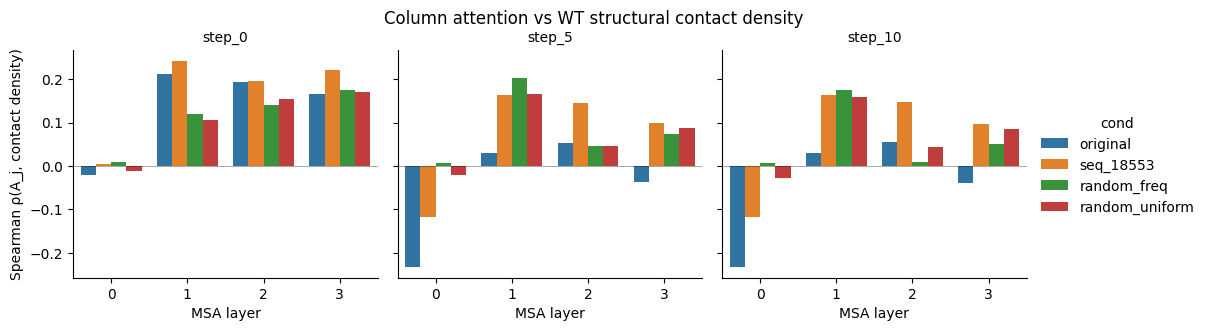

In [18]:
rows = []
for cond in CONDITIONS:
    for s in STEP_KEYS:
        for l in LAYER_IDS:
            a = A[cond][s][l]
            r, _ = spearmanr(a, contact_density)
            rows.append({'cond': cond, 'step': s, 'layer': l, 'rho': r})
df_ct = pd.DataFrame(rows)

g = sns.catplot(
    data=df_ct, x='layer', y='rho', hue='cond', col='step',
    kind='bar', palette=COND_PALETTE, height=3.2, aspect=1.1,
    hue_order=CONDITIONS,
)
for ax in g.axes.flat:
    ax.axhline(0, color='k', lw=0.6, alpha=0.4)
g.set_axis_labels('MSA layer', 'Spearman ρ(A_j, contact density)')
g.set_titles('{col_name}')
g.fig.suptitle('Column attention vs WT structural contact density', y=1.02)
plt.show()


## Reading the result

Cheat-sheet (Boltz uses MSA as a fold prior independent of query):
- Plot 1: `random_*` Spearman bars track `original` at every layer.
- Plot 2: JS(random/WT, original/WT) is small at every layer.
- Plot 3: A_j curves overlap heavily across conditions and track `cons_entropy`.
- Plot 6: `frac_attention_on_muts` is the same for `seq_18553` and the random conditions.

Sequence-aware (model uses query + MSA jointly):
- Spearman drops for `seq_18553` and especially for `random_*` at later layers.
- JS grows with depth between WT-query and random-query conditions.
- `seq_18553` redistributes attention onto/away from mutant positions vs random.